In [1]:
import numpy as truenp

import matplotlib.pyplot as plt
import matplotlib.cm as color
better_magma = color.magma
better_magma.set_bad('black',1.)
import matplotlib.colors as c

from prysm import (
    mathops, 
    conf,
)
from prysm.mathops import (
    np,
    fft,
    interpolate,
    ndimage,
)
from prysm.coordinates import (
    make_xy_grid, 
    cart_to_polar,
)
from prysm.propagation import Wavefront as WF
from prysm.propagation import (
    focus_fixed_sampling,
    focus_fixed_sampling_backprop
)                              
from prysm.thinlens import (
    defocus_to_image_displacement,
    image_displacement_to_defocus,
)
from prysm.geometry import (
    circle,
    spider,
)
from prysm.polynomials import (
    lstsq,
    noll_to_nm,
    zernike_nm,
    zernike_nm_seq,
    hopkins,
    sum_of_2d_modes,
    sum_of_2d_modes_backprop
)
mathops.set_backend_to_cupy()
# conf.config.precision = 32

from astropy.io import (
    fits,
    ascii,
)

from skimage.measure import centroid

from lina.phase_retrieval import ADPR, FDPR, BBPR
from lina.utils import TikhonovInverse

import config_um
import config_um_wcc
from Batoid4LOFT.LAZULI_STOP_mark11 import Lazuli_stop, readBulkMotion, readDeformation

from psd_utils import PSDUtils

from scipy.optimize import minimize

from scipy.interpolate import RegularGridInterpolator

from tqdm import tqdm

from psd_utils import PSDUtils

from model import telescope
from algos import FFPR
import utils

# logging stuff
import logging
psd_log = logging.getLogger('__psd_utils__')
psd_log.disabled = True

%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
!nvidia-smi

Tue Jun 30 13:37:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:25:00.0 Off |                    0 |
| N/A   31C    P0             65W /  300W |    6620MiB /  81920MiB |     10%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
def get_coeffs(sys, pup, fxs, fys, zernikes):

    # initialize array to hold coeffs for field-dependent zernikes at nominal alignment
    coeffs_nom = np.zeros((len(fxs), len(fys), 8))

    # loop through fields
    for i, fx in enumerate(fxs):
        for j, fy in enumerate(fys):

            # get raytrace OPD at field point
            ray_data = sys.get_OPD(fieldX=float(fx.get()), fieldY=float(fy.get()), npx=128)
            opd = np.array(ray_data['wavefront'].array.data * ~ray_data['wavefront'].array.mask)
            opd[~pup] = np.nan

            # decompose
            coeffs_nom[i, j, :] = lstsq(np.array(zernikes), opd)[3:11]
            
    return coeffs_nom

In [4]:
raytrace = Lazuli_stop()

npix = 128
dx = 3065 / npix

x, y = make_xy_grid(shape=npix, diameter=2)
r_norm, t = cart_to_polar(x, y)
nms = [noll_to_nm(i) for i in range(1, 50)]
zernikes = list(zernike_nm_seq(nms, r_norm, t, norm=True))

pup = circle(radius=1, r=r_norm)

# zernikes = [z - np.min(z) for z in zernikes]
# zernikes = [z / np.max(np.abs(z[pup])) for z in zernikes]

# field positions to evaluate
fxs = np.linspace(-16.2, 16.2, 17) / 60
fys = np.linspace(-9.0, 4.8, 7) / 60

# semicircle FOV
Fx, Fy = np.meshgrid(fxs, fys)
semicirc_fov = np.sqrt(Fx ** 2 + (Fy + 14.5) ** 2) <= 19.2
fxs_valid = Fx[semicirc_fov]
fys_valid = Fy[semicirc_fov]

coeffs_nom = get_coeffs(sys=raytrace, pup=pup, fxs=fxs, fys=fys, zernikes=zernikes)

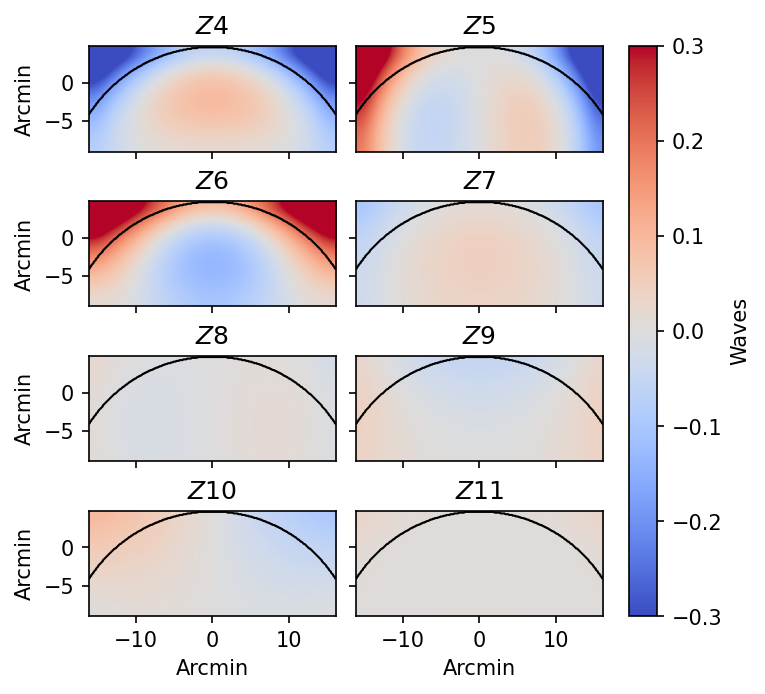

In [11]:
fx = np.linspace(-16.2, 16.2, 325)
fy = np.linspace(-9.0, 4.8, 139)

Fx, Fy = np.meshgrid(fx, fy)
semicirc_fov = np.sqrt(Fx ** 2 + (Fy + 14.5) ** 2) <= 19.2

maps = [coeffs_nom[:, :, i] for i in range(8)]
max = -np.inf
min = np.inf
for map in maps:
    if np.max(map) > max:
        max = np.max(map)
    if np.min(map) < min:
        min = np.min(map)
v = np.max(np.array([np.abs(min), max]))

fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(5, 4.5), layout='constrained', dpi=150)

for i, (map, ax) in enumerate(zip(maps, axs.flat)):
    im = ax.imshow(np.transpose(map).get(), extent=[-16.2, 16.2, -9, 4.8], vmin=-0.3, vmax=0.3, cmap='coolwarm', interpolation='bicubic')
    ax.contour(semicirc_fov.get(), extent=[-16.2, 16.2, -9, 4.8], colors='black', linewidths=1)
    if i in [0, 2, 4, 6]:
        ax.set_ylabel('Arcmin')
    else:
        ax.tick_params(axis='y', labelleft=False)
    if i in [6, 7]:
        ax.set_xlabel('Arcmin')
    else:
        ax.tick_params(axis='x', labelbottom=False)

    ax.set_title(f'$Z{i + 4:.0f}$')

plt.colorbar(im, ax=axs, label='Waves')

In [7]:
ampd = 1e-6
ampt = 1e-6

motion = {'m1' : {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}},
          'm2' : {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}},
          'm3' : {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}},
          'm4' : {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}},}
dofs = ['x', 'y', 'z', 'tip', 'tilt']
optics = ['m1', 'm2', 'm3', 'm4']

lom_interps = {}

for optic in optics:

    optic_interps = {}

    for dof in dofs:

        if dof.__contains__('t'):
            amps = np.linspace(-ampt, ampt, 2)
        else:
            amps = np.linspace(-ampd, ampd, 2)

        coeffs_response = np.zeros(coeffs_nom.shape)

        for amp in amps:

            motion[optic]['user_motion'][dof] = float(amp)

            raytrace = Lazuli_stop(M1_dict=motion['m1'], 
                                M2_dict=motion['m2'],
                                M3_dict=motion['m3'],
                                M4_dict=motion['m4'],
                                motion_loc=1)
            coeffs = get_coeffs(sys=raytrace, pup=pup, fxs=fxs, fys=fys, zernikes=zernikes)
            coeffs_response += (amp * coeffs) / (2 * np.var(amps))

            motion[optic]['user_motion'][dof] = 0

        optic_interps.update({dof : [interpolate.RegularGridInterpolator((fxs * 60, fys * 60), coeffs_response[:, :, z], method='linear') for z in range(8)]})

    lom_interps.update({optic : optic_interps})

In [107]:
utils.save_pickle('/home/derbyk/src/ffpr/data/20260601_lom_interps.pkl', data=lom_interps)

Saved data to:  /home/derbyk/src/ffpr/data/20260601_lom_interps.pkl


In [ ]:
field = (np.array([0]), np.array([0]))

dofs = ['x', 'y', 'z', 'tip', 'tilt']
optics = ['m1', 'm2', 'm3', 'm4']

lom = np.zeros((20, 8))

count = 0
for optic in optics:
    for dof in dofs:
        lom[count, :] = np.array([lom_interps[optic][dof][z](field)[0] * 625 for z in range(8)])
        count += 1

In [30]:
axs.shape

(20, 8)

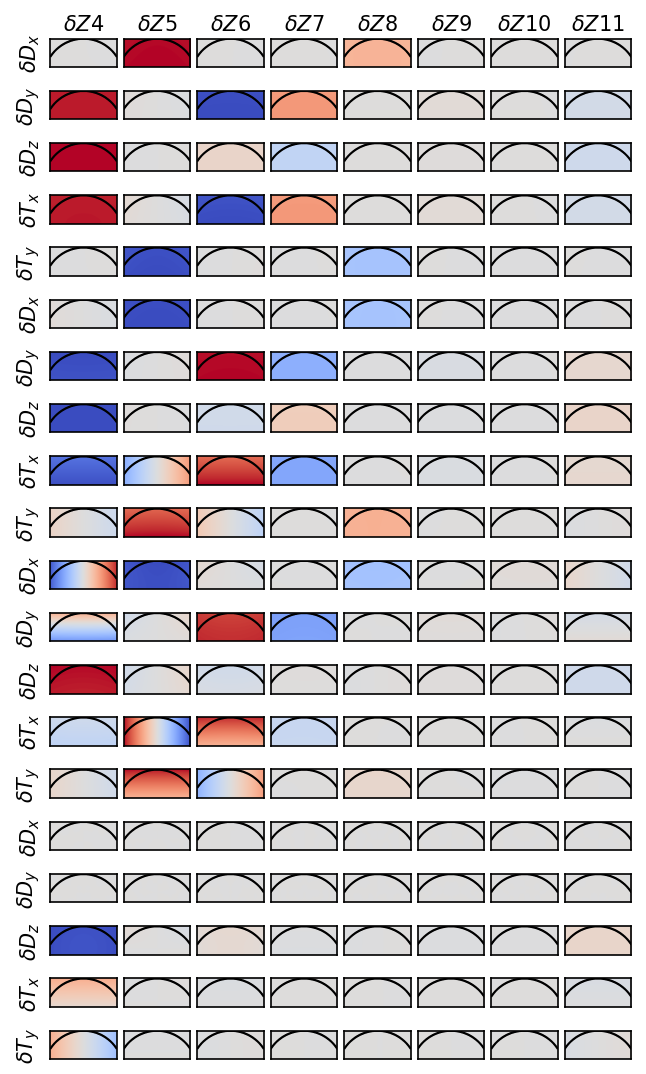

In [32]:
fx = np.linspace(-16.2, 16.2, 325)
fy = np.linspace(-9.0, 4.8, 139)

Fx, Fy = np.meshgrid(fx, fy)
semicirc_fov = np.sqrt(Fx ** 2 + (Fy + 14.5) ** 2) <= 19.2

dofs = ['x', 'y', 'z', 'tip', 'tilt']
dof_labels = ['$D_x$', '$D_y$', '$D_z$', '$T_x$', '$T_y$']
optics = ['m1', 'm2', 'm3', 'm4']

fig, axs = plt.subplots(nrows=20, ncols=8, figsize=(5, 9), dpi=150, gridspec_kw={'wspace': 0.1, 'hspace': 0.1})

count = 0
count2 = 0

for optic in optics:
    for dof in dofs:

        maps = [lom_interps[optic][dof][z]((Fx, Fy)) for z in range(8)]
        max = -np.inf
        min = np.inf
        for map in maps:
            if np.max(map) > max:
                max = np.max(map)
            if np.min(map) < min:
                min = np.min(map)
        v = np.max(np.array([np.abs(min), max]))
        if v < 1e3:
            v = 1e3
        
        axes = axs.flat[count:count + 8]

        for i, (map, ax) in enumerate(zip(maps, axes)):
            im = ax.imshow(map.get(), extent=[-16.2, 16.2, -9, 4.8], vmin=-v, vmax=v, cmap='coolwarm')
            ax.contour(semicirc_fov.get(), extent=[-16.2, 16.2, -9, 4.8], colors='black', linewidths=1)

            ax.tick_params(axis='y', labelleft=False, left=False)
            ax.tick_params(axis='x', labelbottom=False, left=False, bottom=False)

            if count == 0 :
                ax.set_xlabel(f'$\delta Z{i + 4:.0f}$')
                ax.xaxis.set_label_position('top')

            if i == 0:
                ax.set_ylabel('$\delta$' + dof_labels[int(count2 % 5)])

        # plt.colorbar(im, ax=ax)

        count += 8
        count2 += 1

# M3 dx

(array([-2. , -1.5, -1. , -0.5,  0. ,  0.5,  1. ,  1.5,  2. ]),
 [Text(0, -2.0, '−2.0'),
  Text(0, -1.5, '−1.5'),
  Text(0, -1.0, '−1.0'),
  Text(0, -0.5, '−0.5'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.5, '0.5'),
  Text(0, 1.0, '1.0'),
  Text(0, 1.5, '1.5'),
  Text(0, 2.0, '2.0')])

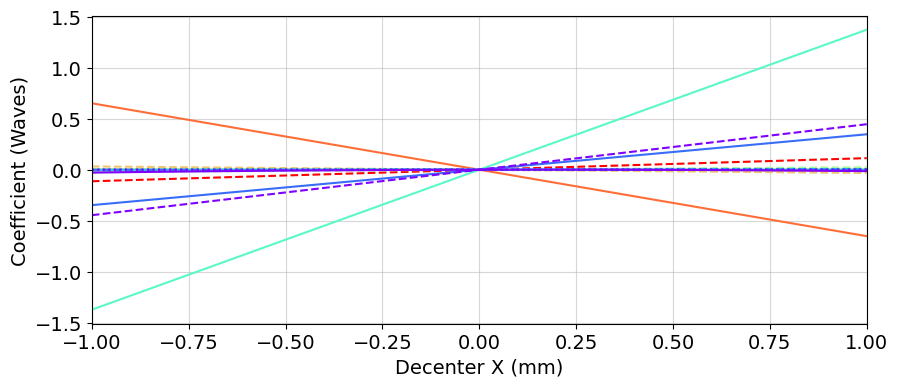

In [7]:
vals = np.linspace(-1e-3, 1e-3, 50)
data = np.zeros((len(vals), len(inds) * 3))

for ind, val in enumerate(vals):

    M1_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}
    M2_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}
    M3_motion = {'user_motion' : {'x' : val.get(), 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}
    M4_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}

    raytrace = Lazuli_stop(M1_dict=M1_motion, M2_dict=M2_motion, M3_dict=M3_motion, M4_dict=M4_motion, motion_loc=1)

    field_coeffs_mis = np.zeros((len(inds), len(fields_x), len(fields_y)))

    # loop through fields
    for i, field_x in enumerate(fields_x):
        for j, field_y in enumerate(fields_y):
            
            # get raytrace OPD at field point
            ray_data = raytrace.get_OPD(fieldX=field_x.get(), fieldY=field_y.get(), npx=npix)
            opd = np.array(ray_data['wavefront'].array.data * ~ray_data['wavefront'].array.mask) * sys.wvl0 * 1e3
            opd[~pupil] = np.nan

            # decompose
            field_coeffs_mis[:, i, j] = lstsq(np.array(zernikes), opd)[inds]

    for i in range(len(inds)):
        data[ind, i * 3] = ((field_coeffs_mis[i, -1, 3] - field_coeffs_nom[i, -1, 3]) - (field_coeffs_mis[i, 0, 3] - field_coeffs_nom[i, 0, 3])) / 4
        data[ind, i * 3 + 1] = ((field_coeffs_mis[i, 3, -1] - field_coeffs_nom[i, 3, -1]) - (field_coeffs_mis[i, 3, 0] - field_coeffs_nom[i, 3, 0])) / 4
        data[ind, i * 3 + 2] = np.mean(field_coeffs_mis[i, :, :] - field_coeffs_nom[i, :, :])

color = iter(plt.cm.rainbow(truenp.linspace(1, 0, 8)))

plt.figure(figsize=(10, 4), dpi=100)
for i in range(len(inds)):
    c = next(color)
    plt.plot(vals.get() * 1e3, data[:, i * 3].get() / 625, label=f'Z{i + 4:.0f}$_A$', c=c, linestyle='dashed')
    plt.plot(vals.get() * 1e3, data[:, i * 3 + 1].get() / 625, label=f'Z{i + 4:.0f}$_B$', c=c, linestyle='dotted')
    plt.plot(vals.get() * 1e3, data[:, i * 3 + 2].get() / 625, label=f'Z{i + 4:.0f}$_C$', c=c)

plt.grid(alpha=0.5)
plt.xlim([-1, 1])
plt.ylabel('Coefficient (Waves)', fontsize=14)
plt.xlabel('Decenter X (mm)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# M3 dy

(array([-2.5, -2. , -1.5, -1. , -0.5,  0. ,  0.5,  1. ,  1.5,  2. ,  2.5]),
 [Text(0, -2.5, '−2.5'),
  Text(0, -2.0, '−2.0'),
  Text(0, -1.5, '−1.5'),
  Text(0, -1.0, '−1.0'),
  Text(0, -0.5, '−0.5'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.5, '0.5'),
  Text(0, 1.0, '1.0'),
  Text(0, 1.5, '1.5'),
  Text(0, 2.0, '2.0'),
  Text(0, 2.5, '2.5')])

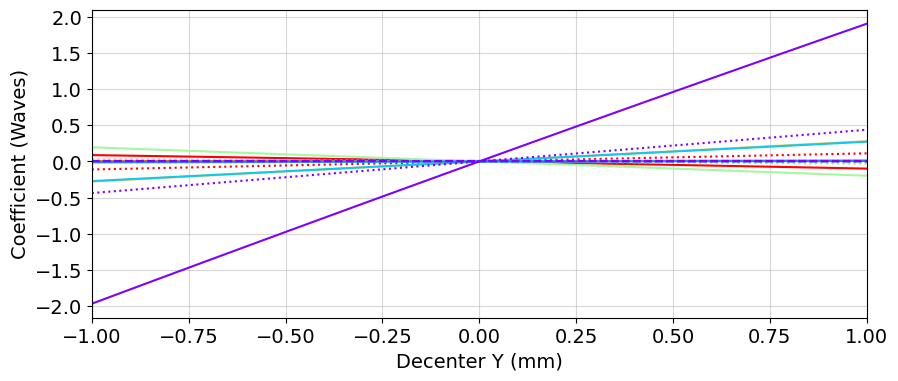

In [8]:
vals = np.linspace(-1e-3, 1e-3, 50)
data = np.zeros((len(vals), len(inds) * 3))

for ind, val in enumerate(vals):

    M1_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}
    M2_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}
    M3_motion = {'user_motion' : {'x' : 0, 'y' : val.get(), 'z' : 0, 'tip' : 0, 'tilt' : 0}}
    M4_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}

    raytrace = Lazuli_stop(M1_dict=M1_motion, M2_dict=M2_motion, M3_dict=M3_motion, M4_dict=M4_motion, motion_loc=1)

    field_coeffs_mis = np.zeros((len(inds), len(fields_x), len(fields_y)))

    # loop through fields
    for i, field_x in enumerate(fields_x):
        for j, field_y in enumerate(fields_y):
            
            # get raytrace OPD at field point
            ray_data = raytrace.get_OPD(fieldX=field_x.get(), fieldY=field_y.get(), npx=npix)
            opd = np.array(ray_data['wavefront'].array.data * ~ray_data['wavefront'].array.mask) * sys.wvl0 * 1e3
            opd[~pupil] = np.nan

            # decompose
            field_coeffs_mis[:, i, j] = lstsq(np.array(zernikes), opd)[inds]

    for i in range(len(inds)):
        data[ind, i * 3] = ((field_coeffs_mis[i, -1, 3] - field_coeffs_nom[i, -1, 3]) - (field_coeffs_mis[i, 0, 3] - field_coeffs_nom[i, 0, 3])) / 4
        data[ind, i * 3 + 1] = ((field_coeffs_mis[i, 3, -1] - field_coeffs_nom[i, 3, -1]) - (field_coeffs_mis[i, 3, 0] - field_coeffs_nom[i, 3, 0])) / 4
        data[ind, i * 3 + 2] = np.mean(field_coeffs_mis[i, :, :] - field_coeffs_nom[i, :, :])

color = iter(plt.cm.rainbow(truenp.linspace(1, 0, 8)))

plt.figure(figsize=(10, 4), dpi=100)
for i in range(len(inds)):
    c = next(color)
    plt.plot(vals.get() * 1e3, data[:, i * 3].get() / 625, label=f'Z{i + 4:.0f}$_A$', c=c, linestyle='dashed')
    plt.plot(vals.get() * 1e3, data[:, i * 3 + 1].get() / 625, label=f'Z{i + 4:.0f}$_B$', c=c, linestyle='dotted')
    plt.plot(vals.get() * 1e3, data[:, i * 3 + 2].get() / 625, label=f'Z{i + 4:.0f}$_C$', c=c)

plt.grid(alpha=0.5)
plt.xlim([-1, 1])
plt.ylabel('Coefficient (Waves)', fontsize=14)
plt.xlabel('Decenter Y (mm)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# M3 dz

(array([-50., -40., -30., -20., -10.,   0.,  10.,  20.,  30.,  40.,  50.]),
 [Text(0, -50.0, '−50'),
  Text(0, -40.0, '−40'),
  Text(0, -30.0, '−30'),
  Text(0, -20.0, '−20'),
  Text(0, -10.0, '−10'),
  Text(0, 0.0, '0'),
  Text(0, 10.0, '10'),
  Text(0, 20.0, '20'),
  Text(0, 30.0, '30'),
  Text(0, 40.0, '40'),
  Text(0, 50.0, '50')])

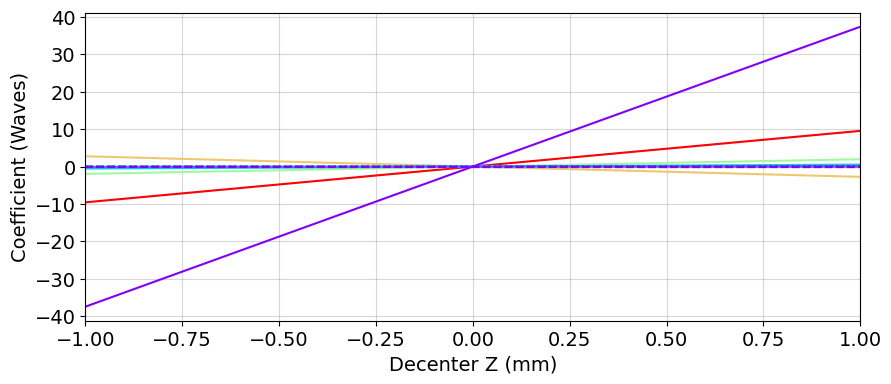

In [9]:
vals = np.linspace(-1e-3, 1e-3, 20)
data = np.zeros((len(vals), len(inds) * 3))

for ind, val in enumerate(vals):

    M1_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}
    M2_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}
    M3_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : val.get(), 'tip' : 0, 'tilt' : 0}}
    M4_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}

    raytrace = Lazuli_stop(M1_dict=M1_motion, M2_dict=M2_motion, M3_dict=M3_motion, M4_dict=M4_motion, motion_loc=1)

    field_coeffs_mis = np.zeros((len(inds), len(fields_x), len(fields_y)))

    # loop through fields
    for i, field_x in enumerate(fields_x):
        for j, field_y in enumerate(fields_y):
            
            # get raytrace OPD at field point
            ray_data = raytrace.get_OPD(fieldX=field_x.get(), fieldY=field_y.get(), npx=npix)
            opd = np.array(ray_data['wavefront'].array.data * ~ray_data['wavefront'].array.mask) * sys.wvl0 * 1e3
            opd[~pupil] = np.nan

            # decompose
            field_coeffs_mis[:, i, j] = lstsq(np.array(zernikes), opd)[inds]

    for i in range(len(inds)):
        data[ind, i * 3] = ((field_coeffs_mis[i, -1, 3] - field_coeffs_nom[i, -1, 3]) - (field_coeffs_mis[i, 0, 3] - field_coeffs_nom[i, 0, 3])) / 4
        data[ind, i * 3 + 1] = ((field_coeffs_mis[i, 3, -1] - field_coeffs_nom[i, 3, -1]) - (field_coeffs_mis[i, 3, 0] - field_coeffs_nom[i, 3, 0])) / 4
        data[ind, i * 3 + 2] = np.mean(field_coeffs_mis[i, :, :] - field_coeffs_nom[i, :, :])

color = iter(plt.cm.rainbow(truenp.linspace(1, 0, 8)))

plt.figure(figsize=(10, 4), dpi=100)
for i in range(len(inds)):
    c = next(color)
    plt.plot(vals.get() * 1e3, data[:, i * 3].get() / 625, label=f'Z{i + 4:.0f}$_A$', c=c, linestyle='dashed')
    plt.plot(vals.get() * 1e3, data[:, i * 3 + 1].get() / 625, label=f'Z{i + 4:.0f}$_B$', c=c, linestyle='dotted')
    plt.plot(vals.get() * 1e3, data[:, i * 3 + 2].get() / 625, label=f'Z{i + 4:.0f}$_C$', c=c)

plt.grid(alpha=0.5)
plt.xlim([-1, 1])
plt.ylabel('Coefficient (Waves)', fontsize=14)
plt.xlabel('Decenter Z (mm)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# M3 tx

(array([-0.2 , -0.15, -0.1 , -0.05,  0.  ,  0.05,  0.1 ,  0.15,  0.2 ]),
 [Text(0, -0.2, '−0.20'),
  Text(0, -0.15000000000000002, '−0.15'),
  Text(0, -0.1, '−0.10'),
  Text(0, -0.04999999999999999, '−0.05'),
  Text(0, 0.0, '0.00'),
  Text(0, 0.04999999999999999, '0.05'),
  Text(0, 0.10000000000000003, '0.10'),
  Text(0, 0.15000000000000002, '0.15'),
  Text(0, 0.2, '0.20')])

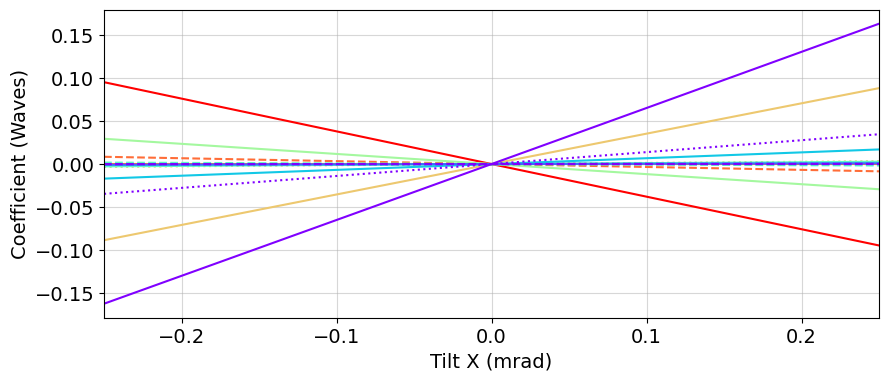

In [11]:
vals = np.linspace(-0.25e-3, 0.25e-3, 10)
data = np.zeros((len(vals), len(inds) * 3))

for ind, val in enumerate(vals):

    M1_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}
    M2_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}
    M3_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : val.get(), 'tilt' : 0}}
    M4_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}

    raytrace = Lazuli_stop(M1_dict=M1_motion, M2_dict=M2_motion, M3_dict=M3_motion, M4_dict=M4_motion, motion_loc=1)

    field_coeffs_mis = np.zeros((len(inds), len(fields_x), len(fields_y)))

    # loop through fields
    for i, field_x in enumerate(fields_x):
        for j, field_y in enumerate(fields_y):
            
            # get raytrace OPD at field point
            ray_data = raytrace.get_OPD(fieldX=field_x.get(), fieldY=field_y.get(), npx=npix)
            opd = np.array(ray_data['wavefront'].array.data * ~ray_data['wavefront'].array.mask) * sys.wvl0 * 1e3
            opd[~pupil] = np.nan

            # decompose
            field_coeffs_mis[:, i, j] = lstsq(np.array(zernikes), opd)[inds]

    for i in range(len(inds)):
        data[ind, i * 3] = ((field_coeffs_mis[i, -1, 3] - field_coeffs_nom[i, -1, 3]) - (field_coeffs_mis[i, 0, 3] - field_coeffs_nom[i, 0, 3])) / 4
        data[ind, i * 3 + 1] = ((field_coeffs_mis[i, 3, -1] - field_coeffs_nom[i, 3, -1]) - (field_coeffs_mis[i, 3, 0] - field_coeffs_nom[i, 3, 0])) / 4
        data[ind, i * 3 + 2] = np.mean(field_coeffs_mis[i, :, :] - field_coeffs_nom[i, :, :])

color = iter(plt.cm.rainbow(truenp.linspace(1, 0, 8)))

plt.figure(figsize=(10, 4), dpi=100)
for i in range(len(inds)):
    c = next(color)
    plt.plot(vals.get() * 1e3, data[:, i * 3].get() / 625, label=f'Z{i + 4:.0f}$_A$', c=c, linestyle='dashed')
    plt.plot(vals.get() * 1e3, data[:, i * 3 + 1].get() / 625, label=f'Z{i + 4:.0f}$_B$', c=c, linestyle='dotted')
    plt.plot(vals.get() * 1e3, data[:, i * 3 + 2].get() / 625, label=f'Z{i + 4:.0f}$_C$', c=c)

plt.grid(alpha=0.5)
plt.xlim([-0.25, 0.25])
plt.ylabel('Coefficient (Waves)', fontsize=14)
plt.xlabel('Tilt X (mrad)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# M3 ty

(array([-0.2 , -0.15, -0.1 , -0.05,  0.  ,  0.05,  0.1 ,  0.15,  0.2 ]),
 [Text(0, -0.2, '−0.20'),
  Text(0, -0.15000000000000002, '−0.15'),
  Text(0, -0.1, '−0.10'),
  Text(0, -0.04999999999999999, '−0.05'),
  Text(0, 0.0, '0.00'),
  Text(0, 0.04999999999999999, '0.05'),
  Text(0, 0.10000000000000003, '0.10'),
  Text(0, 0.15000000000000002, '0.15'),
  Text(0, 0.2, '0.20')])

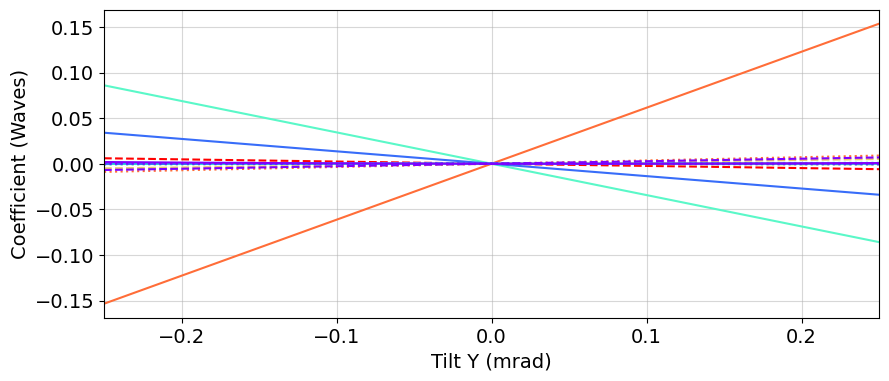

In [12]:
vals = np.linspace(-0.25e-3, 0.25e-3, 10)
data = np.zeros((len(vals), len(inds) * 3))

for ind, val in enumerate(vals):

    M1_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}
    M2_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}
    M3_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : val.get()}}
    M4_motion = {'user_motion' : {'x' : 0, 'y' : 0, 'z' : 0, 'tip' : 0, 'tilt' : 0}}

    raytrace = Lazuli_stop(M1_dict=M1_motion, M2_dict=M2_motion, M3_dict=M3_motion, M4_dict=M4_motion, motion_loc=1)

    field_coeffs_mis = np.zeros((len(inds), len(fields_x), len(fields_y)))

    # loop through fields
    for i, field_x in enumerate(fields_x):
        for j, field_y in enumerate(fields_y):
            
            # get raytrace OPD at field point
            ray_data = raytrace.get_OPD(fieldX=field_x.get(), fieldY=field_y.get(), npx=npix)
            opd = np.array(ray_data['wavefront'].array.data * ~ray_data['wavefront'].array.mask) * sys.wvl0 * 1e3
            opd[~pupil] = np.nan

            # decompose
            field_coeffs_mis[:, i, j] = lstsq(np.array(zernikes), opd)[inds]

    for i in range(len(inds)):
        data[ind, i * 3] = ((field_coeffs_mis[i, -1, 3] - field_coeffs_nom[i, -1, 3]) - (field_coeffs_mis[i, 0, 3] - field_coeffs_nom[i, 0, 3])) / 4
        data[ind, i * 3 + 1] = ((field_coeffs_mis[i, 3, -1] - field_coeffs_nom[i, 3, -1]) - (field_coeffs_mis[i, 3, 0] - field_coeffs_nom[i, 3, 0])) / 4
        data[ind, i * 3 + 2] = np.mean(field_coeffs_mis[i, :, :] - field_coeffs_nom[i, :, :])

color = iter(plt.cm.rainbow(truenp.linspace(1, 0, 8)))

plt.figure(figsize=(10, 4), dpi=100)
for i in range(len(inds)):
    c = next(color)
    plt.plot(vals.get() * 1e3, data[:, i * 3].get() / 625, label=f'Z{i + 4:.0f}$_A$', c=c, linestyle='dashed')
    plt.plot(vals.get() * 1e3, data[:, i * 3 + 1].get() / 625, label=f'Z{i + 4:.0f}$_B$', c=c, linestyle='dotted')
    plt.plot(vals.get() * 1e3, data[:, i * 3 + 2].get() / 625, label=f'Z{i + 4:.0f}$_C$', c=c)

plt.grid(alpha=0.5)
plt.xlim([-0.25, 0.25])
plt.ylabel('Coefficient (Waves)', fontsize=14)
plt.xlabel('Tilt Y (mrad)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# just for legend

(array([-0.2 , -0.15, -0.1 , -0.05,  0.  ,  0.05,  0.1 ,  0.15,  0.2 ]),
 [Text(0, -0.2, '−0.20'),
  Text(0, -0.15000000000000002, '−0.15'),
  Text(0, -0.1, '−0.10'),
  Text(0, -0.04999999999999999, '−0.05'),
  Text(0, 0.0, '0.00'),
  Text(0, 0.04999999999999999, '0.05'),
  Text(0, 0.10000000000000003, '0.10'),
  Text(0, 0.15000000000000002, '0.15'),
  Text(0, 0.2, '0.20')])

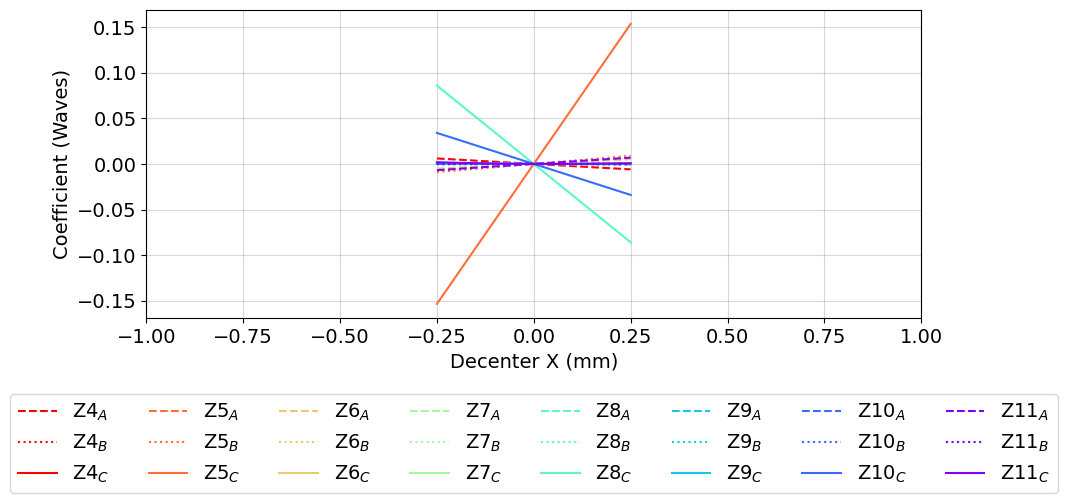

In [13]:
color = iter(plt.cm.rainbow(truenp.linspace(1, 0, 8)))

plt.figure(figsize=(10, 4), dpi=100)
for i in range(len(inds)):
    c = next(color)
    plt.plot(vals.get() * 1e3, data[:, i * 3].get() / 625, label=f'Z{i + 4:.0f}$_A$', c=c, linestyle='dashed')
    plt.plot(vals.get() * 1e3, data[:, i * 3 + 1].get() / 625, label=f'Z{i + 4:.0f}$_B$', c=c, linestyle='dotted')
    plt.plot(vals.get() * 1e3, data[:, i * 3 + 2].get() / 625, label=f'Z{i + 4:.0f}$_C$', c=c)

plt.legend(ncol=8, loc='lower center', bbox_to_anchor=(0.5, -0.6), fontsize=14)
plt.grid(alpha=0.5)
plt.xlim([-1, 1])
plt.ylabel('Coefficient (Waves)', fontsize=14)
plt.xlabel('Decenter X (mm)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)